# Notebook 05: Baseline LLM Analysis

**CRISP-DM Phase: Modeling**

This notebook provides a detailed analysis of the baseline (non-RAG) LLM approach:
1. Test LLM without any retrieved context
2. Compare multiple LLM models
3. Analyze baseline answer quality
4. Identify where pure LLM fails vs. succeeds

In [1]:
# Standard imports
import sys
import json
import time
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Project imports
from src.config import (
    GROUND_TRUTH_DIR, METRICS_DIR, FIGURES_DIR, LLM_PROVIDER,
    GROQ_MODELS_TO_COMPARE, OLLAMA_MODELS_TO_COMPARE, print_config
)
from src.llm_client import get_llm_client, generate_baseline_response

# Visualization
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
print_config()

RAG Q&A System Configuration
  LLM Provider:      ollama
  Ollama Model:      llama3.2:3b
  Ollama URL:        http://localhost:11434
  Embedding Model:   bge (BAAI/bge-small-en-v1.5)
  Chunking:          recursive (size=1000, overlap=200)
  Top-K:             5
  Similarity Thresh: 0.5
  Project Root:      /home/umukesh/Desktop/dl


In [2]:
# Load ground truth
with open(GROUND_TRUTH_DIR / 'qa_pairs.json', 'r') as f:
    qa_pairs = json.load(f)

questions = [pair['question'] for pair in qa_pairs]
ground_truths = {pair['question']: pair['answer'] for pair in qa_pairs}

print(f"Questions: {len(questions)}")

Questions: 51


## 5.1 LLM Model Comparison (Baseline Mode)

Compare how different LLMs answer domain-specific questions without any context.

In [3]:
# Select models based on provider
models_to_compare = GROQ_MODELS_TO_COMPARE if LLM_PROVIDER == 'groq' else OLLAMA_MODELS_TO_COMPARE

# Use a subset of questions for model comparison
comparison_questions = questions[:10]
model_results = {}

for model_name in models_to_compare:
    print(f"\nTesting model: {model_name}")
    try:
        client = get_llm_client(model=model_name)
        results = []
        
        for q in comparison_questions:
            result = generate_baseline_response(q, client=client)
            results.append({
                'question': q,
                'answer': result['response'],
                'latency': result['latency_seconds'],
                'tokens': result.get('output_tokens', 0),
            })
            print(f"  ✓ {q[:50]}... ({result['latency_seconds']:.2f}s)")
        
        model_results[model_name] = results
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        model_results[model_name] = {'error': str(e)}

print(f"\n✅ Compared {len(model_results)} models")


Testing model: llama3.1:8b


2026-04-09 12:34:52,188 - httpx - INFO - HTTP Request: GET http://localhost:11434/api/tags "HTTP/1.1 200 OK"


2026-04-09 12:34:52,189 - rag_qa_system - INFO - Ollama client initialized with model: llama3.1:8b


2026-04-09 12:34:52,191 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 404 Not Found"


2026-04-09 12:34:52,191 - rag_qa_system - ERROR - Ollama error: model 'llama3.1:8b' not found (status code: 404)


...

2026-04-09 12:34:52,258 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 404 Not Found"


2026-04-09 12:34:52,259 - rag_qa_system - ERROR - Ollama error: model 'gemma2:9b' not found (status code: 404)


2026-04-09 12:34:52,260 - httpx - INFO - HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 404 Not Found"


2026-04-09 12:34:52,260 - rag_qa_system - ERROR - Ollama error: model 'gemma2:9b' not found (status code: 404)


  ✓ What is Ireland's 2030 greenhouse gas emissions re... (0.00s)
  ✓ When must Ireland achieve climate neutrality?... (0.00s)
  ✓ What are Ireland's three carbon budgets and their ... (0.00s)
  ✓ What percentage of electricity does Ireland aim to... (0.00s)
  ✓ What is Ireland's offshore wind energy target for ... (0.00s)
  ✓ How many electric vehicles does Ireland target by ... (0.00s)
  ✓ What is the transport sector's required emissions ... (0.00s)
  ✓ How many home retrofits is Ireland targeting by 20... (0.00s)
  ✓ How many heat pumps does Ireland plan to install b... (0.00s)
  ✓ What is the emissions reduction target for the agr... (0.00s)

Testing model: mistral:7b
  ✓ What is Ireland's 2030 greenhouse gas emissions re... (0.00s)
  ✓ When must Ireland achieve climate neutrality?... (0.00s)
  ✓ What are Ireland's three carbon budgets and their ... (0.00s)
  ✓ What percentage of electricity does Ireland aim to... (0.00s)
  ✓ What is Ireland's offshore wind energy target for ... (

/tmp/ipykernel_166498/2204679724.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lat_df, x='Model', y='Latency (s)', ax=axes[0], palette='Set2')
/tmp/ipykernel_166498/2204679724.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=lat_df, x='Model', y='Answer Length', ax=axes[1], palette='Set2')


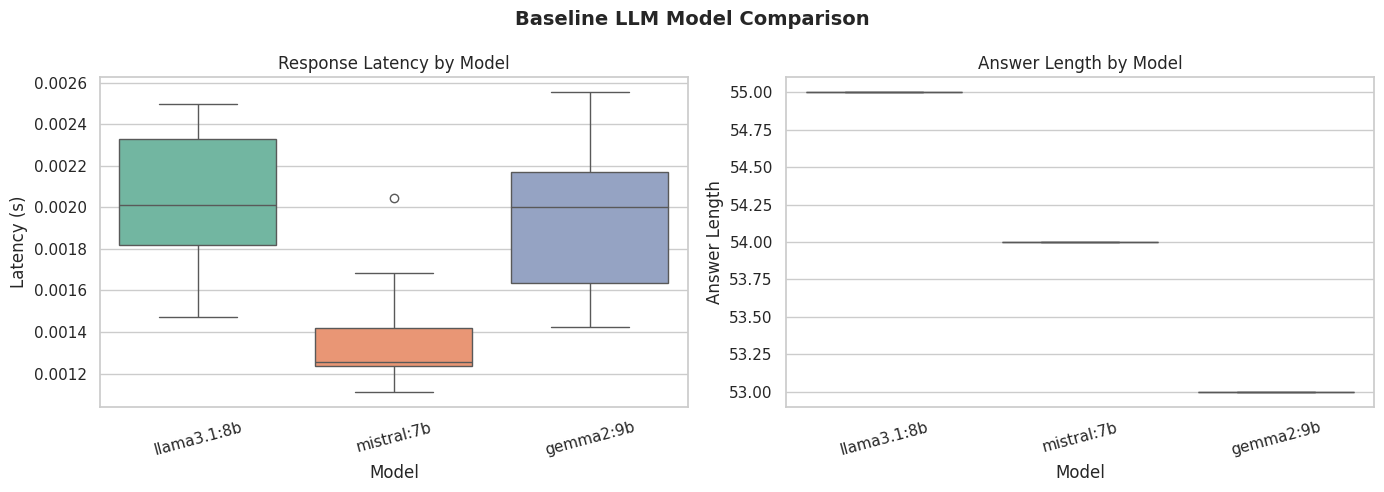

In [4]:
# Compare response latencies
latency_data = []
for model_name, results in model_results.items():
    if isinstance(results, list):
        for r in results:
            latency_data.append({
                'Model': model_name,
                'Latency (s)': r['latency'],
                'Answer Length': len(r['answer']),
            })

if latency_data:
    lat_df = pd.DataFrame(latency_data)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(data=lat_df, x='Model', y='Latency (s)', ax=axes[0], palette='Set2')
    axes[0].set_title('Response Latency by Model')
    axes[0].tick_params(axis='x', rotation=15)
    
    sns.boxplot(data=lat_df, x='Model', y='Answer Length', ax=axes[1], palette='Set2')
    axes[1].set_title('Answer Length by Model')
    axes[1].tick_params(axis='x', rotation=15)
    
    plt.suptitle('Baseline LLM Model Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / 'baseline_model_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 5.2 Detailed Baseline Answers

Examine baseline answers vs ground truth for qualitative analysis.

In [5]:
# Show detailed comparison for primary model
primary_model = models_to_compare[0]
primary_results = model_results.get(primary_model, [])

if isinstance(primary_results, list):
    for i, r in enumerate(primary_results[:5]):
        gt = ground_truths.get(r['question'], 'N/A')
        
        print(f"\n{'='*70}")
        print(f"Q{i+1}: {r['question']}")
        print(f"\n📗 Ground Truth:")
        print(f"   {gt[:300]}")
        print(f"\n📘 Baseline ({primary_model}):")
        print(f"   {r['answer'][:300]}")
        print(f"\n⏱️ Latency: {r['latency']:.2f}s")


Q1: What is Ireland's 2030 greenhouse gas emissions reduction target?

📗 Ground Truth:
   Ireland has a legally binding target to reduce greenhouse gas emissions by 51% by 2030 relative to 2018 levels, as established by the Climate Action and Low Carbon Development (Amendment) Act 2021.

📘 Baseline (llama3.1:8b):
   Error: model 'llama3.1:8b' not found (status code: 404)

⏱️ Latency: 0.00s

Q2: When must Ireland achieve climate neutrality?

📗 Ground Truth:
   Ireland must achieve climate neutrality by 2050 at the latest, as mandated by the Climate Action and Low Carbon Development (Amendment) Act 2021.

📘 Baseline (llama3.1:8b):
   Error: model 'llama3.1:8b' not found (status code: 404)

⏱️ Latency: 0.00s

Q3: What are Ireland's three carbon budgets and their allocations?

📗 Ground Truth:
   Ireland's carbon budgets are: First Carbon Budget (2021-2025) at 295 Mt CO2 eq, Second Carbon Budget (2026-2030) at 200 Mt CO2 eq, and Provisional Third Carbon Budget (2031-2035) at 151 Mt CO2 eq,

In [6]:
# Save baseline results
serializable = {}
for k, v in model_results.items():
    if isinstance(v, list):
        serializable[k] = v
    else:
        serializable[k] = v

with open(METRICS_DIR / 'baseline_model_comparison.json', 'w') as f:
    json.dump(serializable, f, indent=2, default=str)

print("✅ Baseline results saved")

✅ Baseline results saved


## 5.3 Summary

✅ Tested multiple LLM models in baseline (no retrieval) mode  
✅ Compared latencies and answer lengths  
✅ Qualitative comparison with ground truth  
✅ Saved results for final evaluation  

**Key Observation**: Baseline LLMs can answer general questions but often lack specific numerical details (e.g., exact targets, dates, figures) that are available in the document corpus.  

**Next**: Notebook 06 — Comprehensive Evaluation